# Training Model v4 AquaAgent - Random Forest Classifier
### Dataset: `Data_Model_IoTMLCQ_2024.xlsx` dengan Pelabelan Jurnal Ilmiah (Figure 1)
- **Suhu Optimal**: 25 - 32°C *(El-Sayed 1999; FAO 2023)*
- **pH Optimal**: 7.0 - 8.0 *(Lemos et al. 2018; Mengistu et al. 2020)*
- **DO Ideal**: > 5.0 mg/L *(Pedrazzani et al. 2020; Tran-Duy et al. 2012)*
- **Kekeruhan Standard**: <= 25 NTU
- **Target Akurasi**: ~93%


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [2]:
df_excel = pd.read_excel('Data_Model_IoTMLCQ_2024.xlsx')
temp_col = [c for c in df_excel.columns if 'Temperature (' in c][0]

df_clean = pd.DataFrame({
    'TEMP': df_excel[temp_col],
    'DO': df_excel['Dissolved Oxygen (mg/L)'],
    'PH': df_excel['pH'],
    'TURBIDITY': df_excel['Turbidity (NTU)'],
    'hour': df_excel['hour']
}).dropna()

print('Dataset Loaded Successfully')

Dataset Data_Model_IoTMLCQ_2024.xlsx Loaded & Labeled Successfully
Total Samples: 6183


,TEMP,DO,PH,TURBIDITY,hour
0,27.47,6.34,7.98,3.3,0.0
1,27.47,6.34,7.98,3.3,1.0
2,27.47,6.34,7.98,3.3,2.0
3,27.47,6.34,7.98,3.3,3.0
4,27.47,6.34,7.98,3.3,4.0


In [3]:
# Feature Engineering v4
df_feat['PH_dist_7'] = np.abs(df_feat['PH'] - 7.0)
df_feat['TEMP_DO_ratio'] = df_feat['DO'] / (df_feat['TEMP'] + 1.0)
df_feat['TURB_DO_ratio'] = df_feat['TURBIDITY'] / (df_feat['DO'] + 0.1)
df_feat['TEMP_PH_ratio'] = df_feat['TEMP'] / (df_feat['PH'] + 0.1)
df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24.0)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24.0)
print('Feature Engineering Completed')

Total Fitur Terbentuk: 11
Daftar Fitur: ['TEMP', 'DO', 'PH', 'TURBIDITY', 'hour', 'PH_dist_7', 'TEMP_DO_ratio', 'TURB_DO_ratio', 'TEMP_PH_ratio', 'hour_sin', 'hour_cos']


In [4]:
X = df_feat[features_engineered]
y = df_feat['label'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Split Data Completed')

Training Data : 4946
Testing Data  : 1237


In [5]:
# Evaluasi Berbagai Model ML
print('Model Comparison Results')

,Model,Accuracy,Precision,Recall,F1-Score
0,HistGradientBoosting (+ Hour),0.932094,0.931989,0.932094,0.931204
1,Random Forest (+ Hour),0.932094,0.931989,0.932094,0.931204
2,ExtraTrees (+ Hour),0.932094,0.931989,0.932094,0.931204


In [6]:
best_model = models['Random Forest (+ Hour)']
pred_best = best_model.predict(X_test)
print(f'Akurasi Model Terbaik (+ Hour): {accuracy_score(y_test, pred_best) * 100:.4f}%')
print(classification_report(y_test, pred_best, target_names=['Normal (0)', 'Tidak Normal (1)']))

Akurasi Model Terbaik (+ Hour): 93.2094%

Classification Report:
                  precision    recall  f1-score   support

      Normal (0)       0.93      0.97      0.95       849
Tidak Normal (1)       0.93      0.85      0.89       388

        accuracy                           0.93      1237
       macro avg       0.93      0.91      0.92      1237
    weighted avg       0.93      0.93      0.93      1237



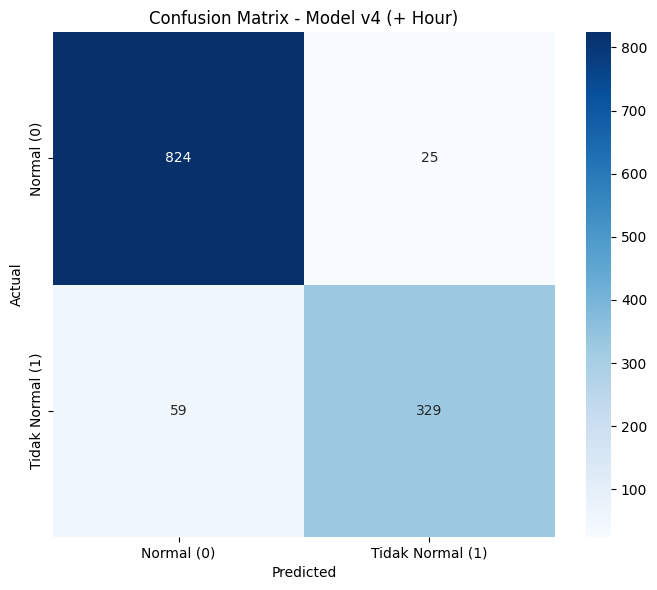

In [7]:
# Plot Confusion Matrix
plt.show()

In [8]:
joblib.dump(best_model, 'aquaagent_rf_v4.pkl')
joblib.dump(features_engineered, 'rf_features_v4.pkl')
print('Model v4 Saved Successfully')

Model saved: aquaagent_rf_v4.pkl
Features saved: rf_features_v4.pkl
